In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")
plasma = get_cmap("plasma")
viridis = get_cmap("viridis")
magma = get_cmap("magma")

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo0 version:", amigo.__version__)
print("dorito version:", dorito.__version__)

ERROR:2026-09-08 06:37:50,037:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


cpu
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo0 version: 0.0.10
dorito version: 0.2.0


In [2]:
# Setting data path
from socket import gethostname

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/outputs/retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"


print(f"amigo_files_path: {amigo_files_path}")

host name: max-cpuv5-0-1
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
import importlib

resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")

with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)
    
def add_badpix(file):
    file["BADPIX"].data = badpix
    # file["BADPIX"].data[25, 74] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files
from dorito.misc import truncate_files


dark_files = []
print()
print("DARKS")
program_path = os.path.join(data_dir, "DARKS/uncal/")
files = get_files(program_path, "_uncal", EXP_TYPE="NIS_DARK")
dark_files += files

# dark_files = [add_badpix(file) for file in dark_files]
# truncate_files(dark_files, 500)  # TRUNCATING RAMP
summarise_files(dark_files)

file_800, file_050 = dark_files


DARKS
  program   target filter dither     g/i date             PI   CAL
0    1499  UNKNOWN  F430M    1/1  800/30  NaN  Martel, Andre  FLAT
1    6652  UNKNOWN  F430M    1/1  50/469  NaN  Martel, Andre  FLAT


In [5]:
import numpy as onp
from astropy.stats import sigma_clip

def apply_sigma_clip(data, sigma=5.0, axis=0):
    """NOTE: casts bad values to nan, so output must be float array"""
    # Mask invalid values (nans, infs, etc.)
    masked = onp.ma.masked_invalid(data, copy=True)

    # Apply sigma clipping
    clipped = sigma_clip(masked, axis=axis, sigma=sigma)

    # Fill clipped/invalid values with -1
    data = np.array(onp.ma.filled(clipped, fill_value=-1), dtype=float)

    # Cast bad values to nan now that it is guaranteed a float array
    return data.at[np.where(data == -1.0)].set(np.nan)


def check_darks(data):
    top_group = data[:, -1, ...]
    bottom_group = data[:, 0, ...]
    
    fig, ax = plt.subplots(2, 3, figsize=(11, 5))
    
    # mean top group
    im = ax[0][0].imshow(np.nanmean(top_group, axis=0), inferno)
    fig.colorbar(im)
    ax[0][0].axis("off")
    ax[0][0].set(title=f"Mean Top ({data.shape[1]}) Group")
    
    # mean bottom group
    im = ax[0][1].imshow(np.nanmean(bottom_group, axis=0), inferno)
    fig.colorbar(im)
    ax[0][1].axis("off")
    ax[0][1].set(title="Mean Bottom Group")
    
    # mean top - bottom group
    im = ax[0][2].imshow(np.nanmean(top_group - bottom_group, axis=0), inferno)
    fig.colorbar(im)
    ax[0][2].axis("off")
    ax[0][2].set(title="Mean Top - Bottom Group")
    
    # std top group
    im = ax[1][0].imshow(np.nanstd(top_group, axis=0), viridis, norm=mpl.colors.PowerNorm(0.5))
    fig.colorbar(im)
    ax[1][0].axis("off")
    ax[1][0].set(title=f"Std Top ({data.shape[1]}) Group")
    
    # std bottom group
    im = ax[1][1].imshow(np.nanstd(bottom_group, axis=0), viridis, norm=mpl.colors.PowerNorm(0.5))
    fig.colorbar(im)
    ax[1][1].axis("off")
    ax[1][1].set(title="Std Bottom Group")
    
    # std top - bottom group
    im = ax[1][2].imshow(np.nanstd(top_group - bottom_group, axis=0), viridis, norm=mpl.colors.PowerNorm(0.5))
    fig.colorbar(im)
    ax[1][2].axis("off")
    ax[1][2].set(title="Std Top - Bottom Group")
    
    plt.show()

In [6]:
data = np.where(badpix, np.nan, file_050["SCI"].data)
clipped_data = apply_sigma_clip(data)

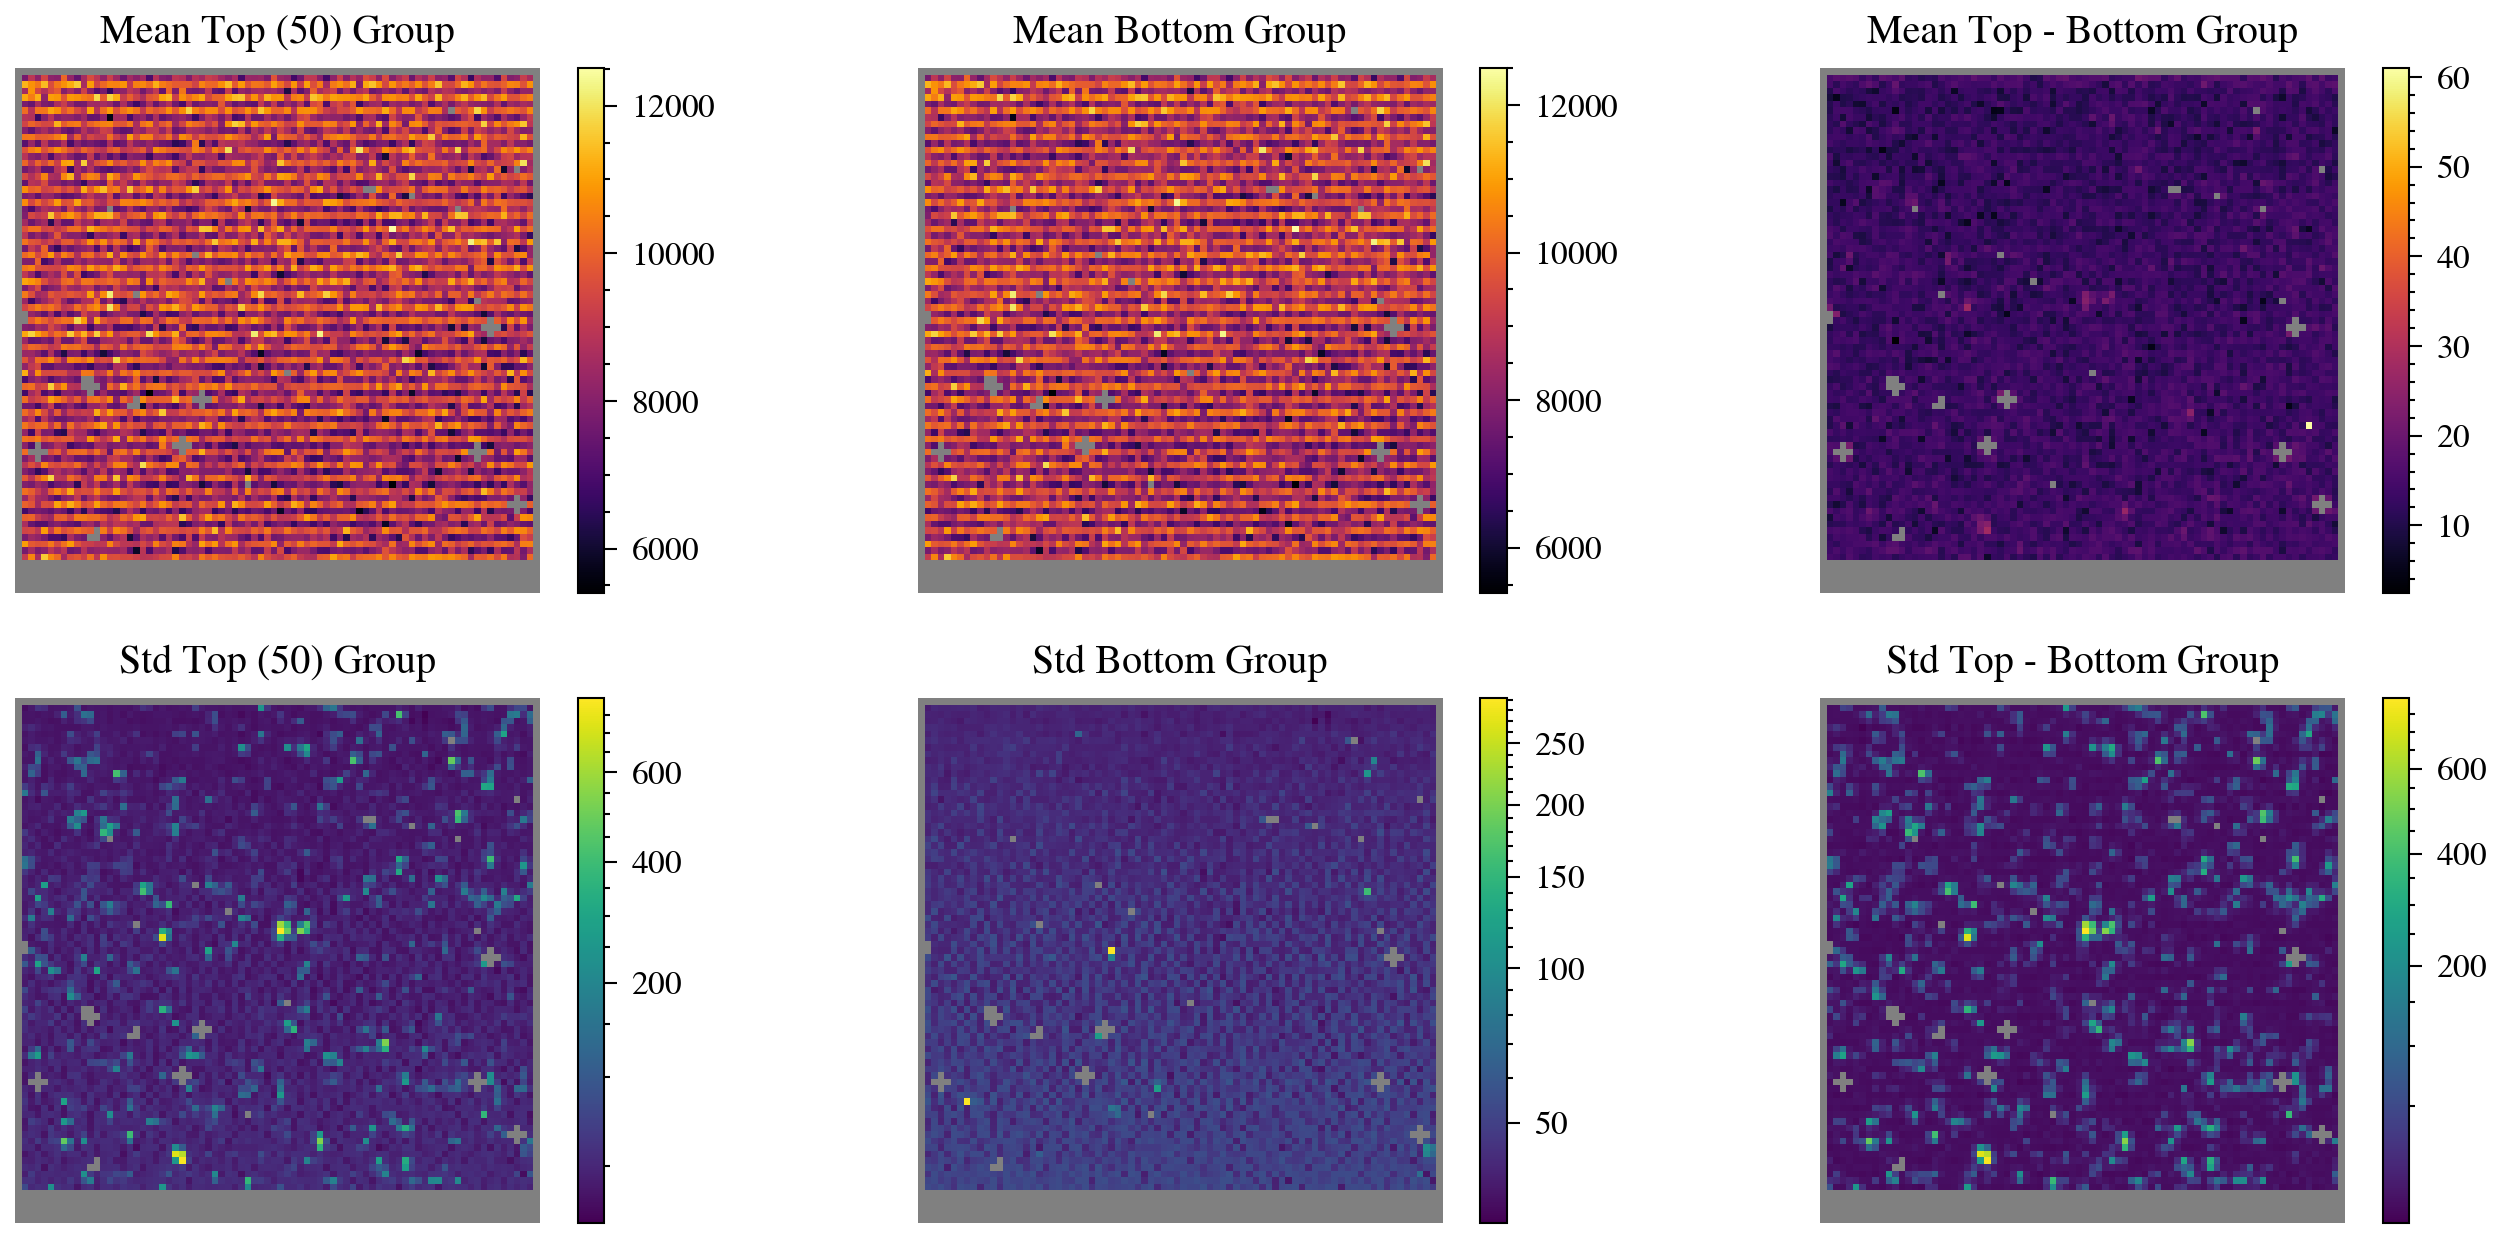

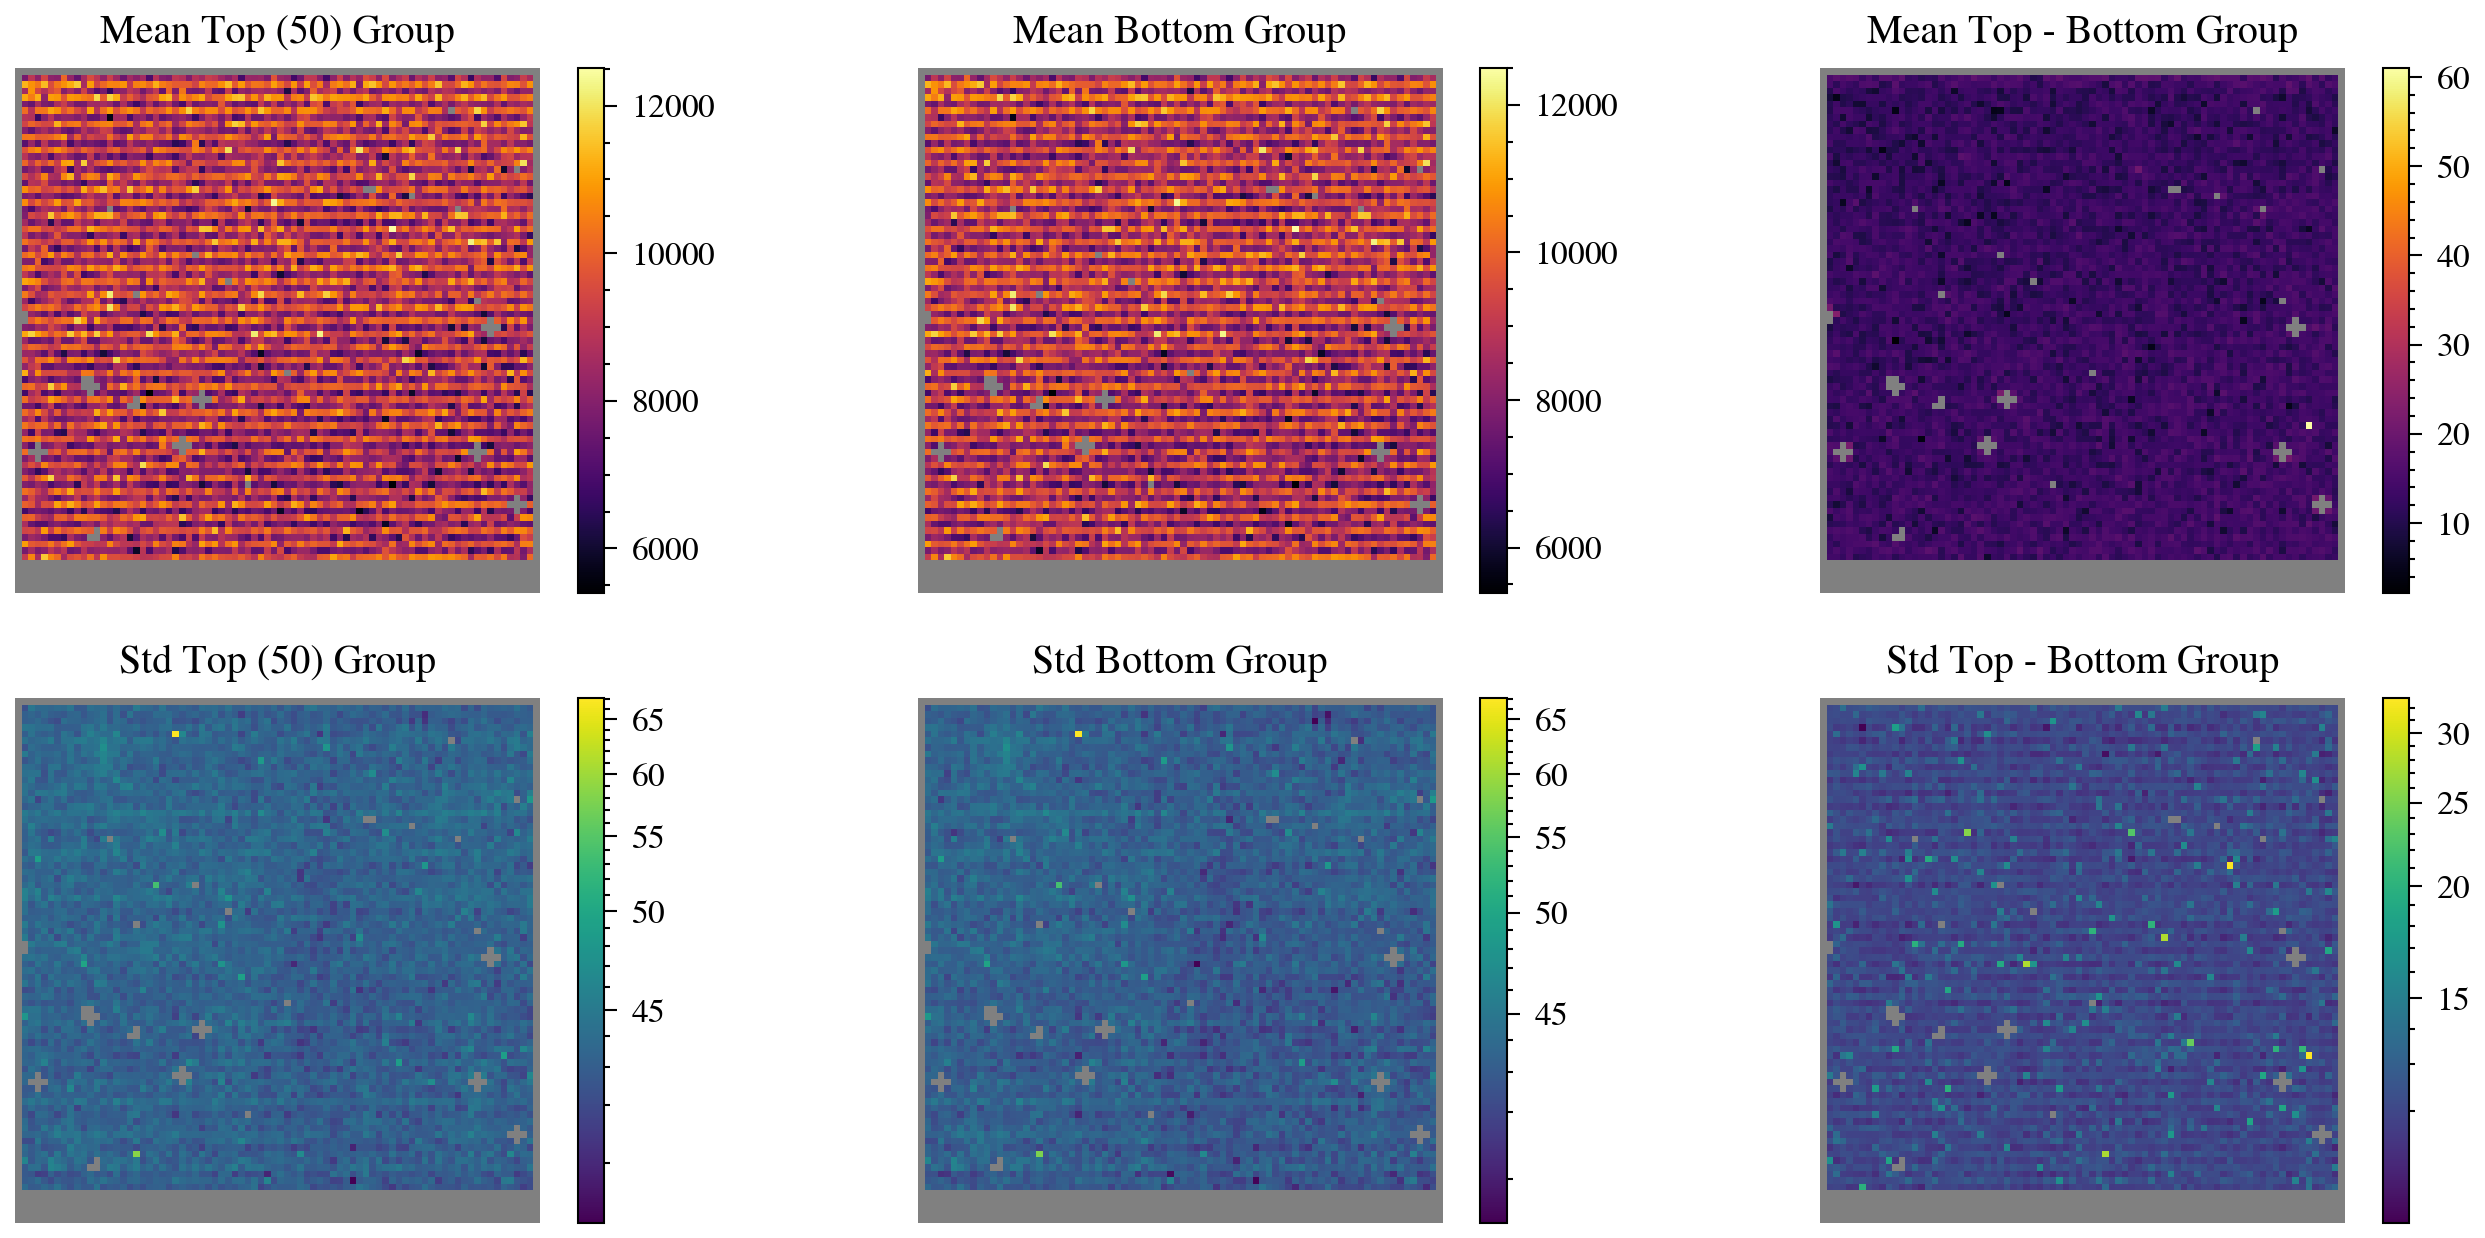

In [7]:
check_darks(data)
check_darks(clipped_data)

In [8]:
data = np.where(badpix, np.nan, file_800["SCI"].data)
clipped_data = apply_sigma_clip(data)

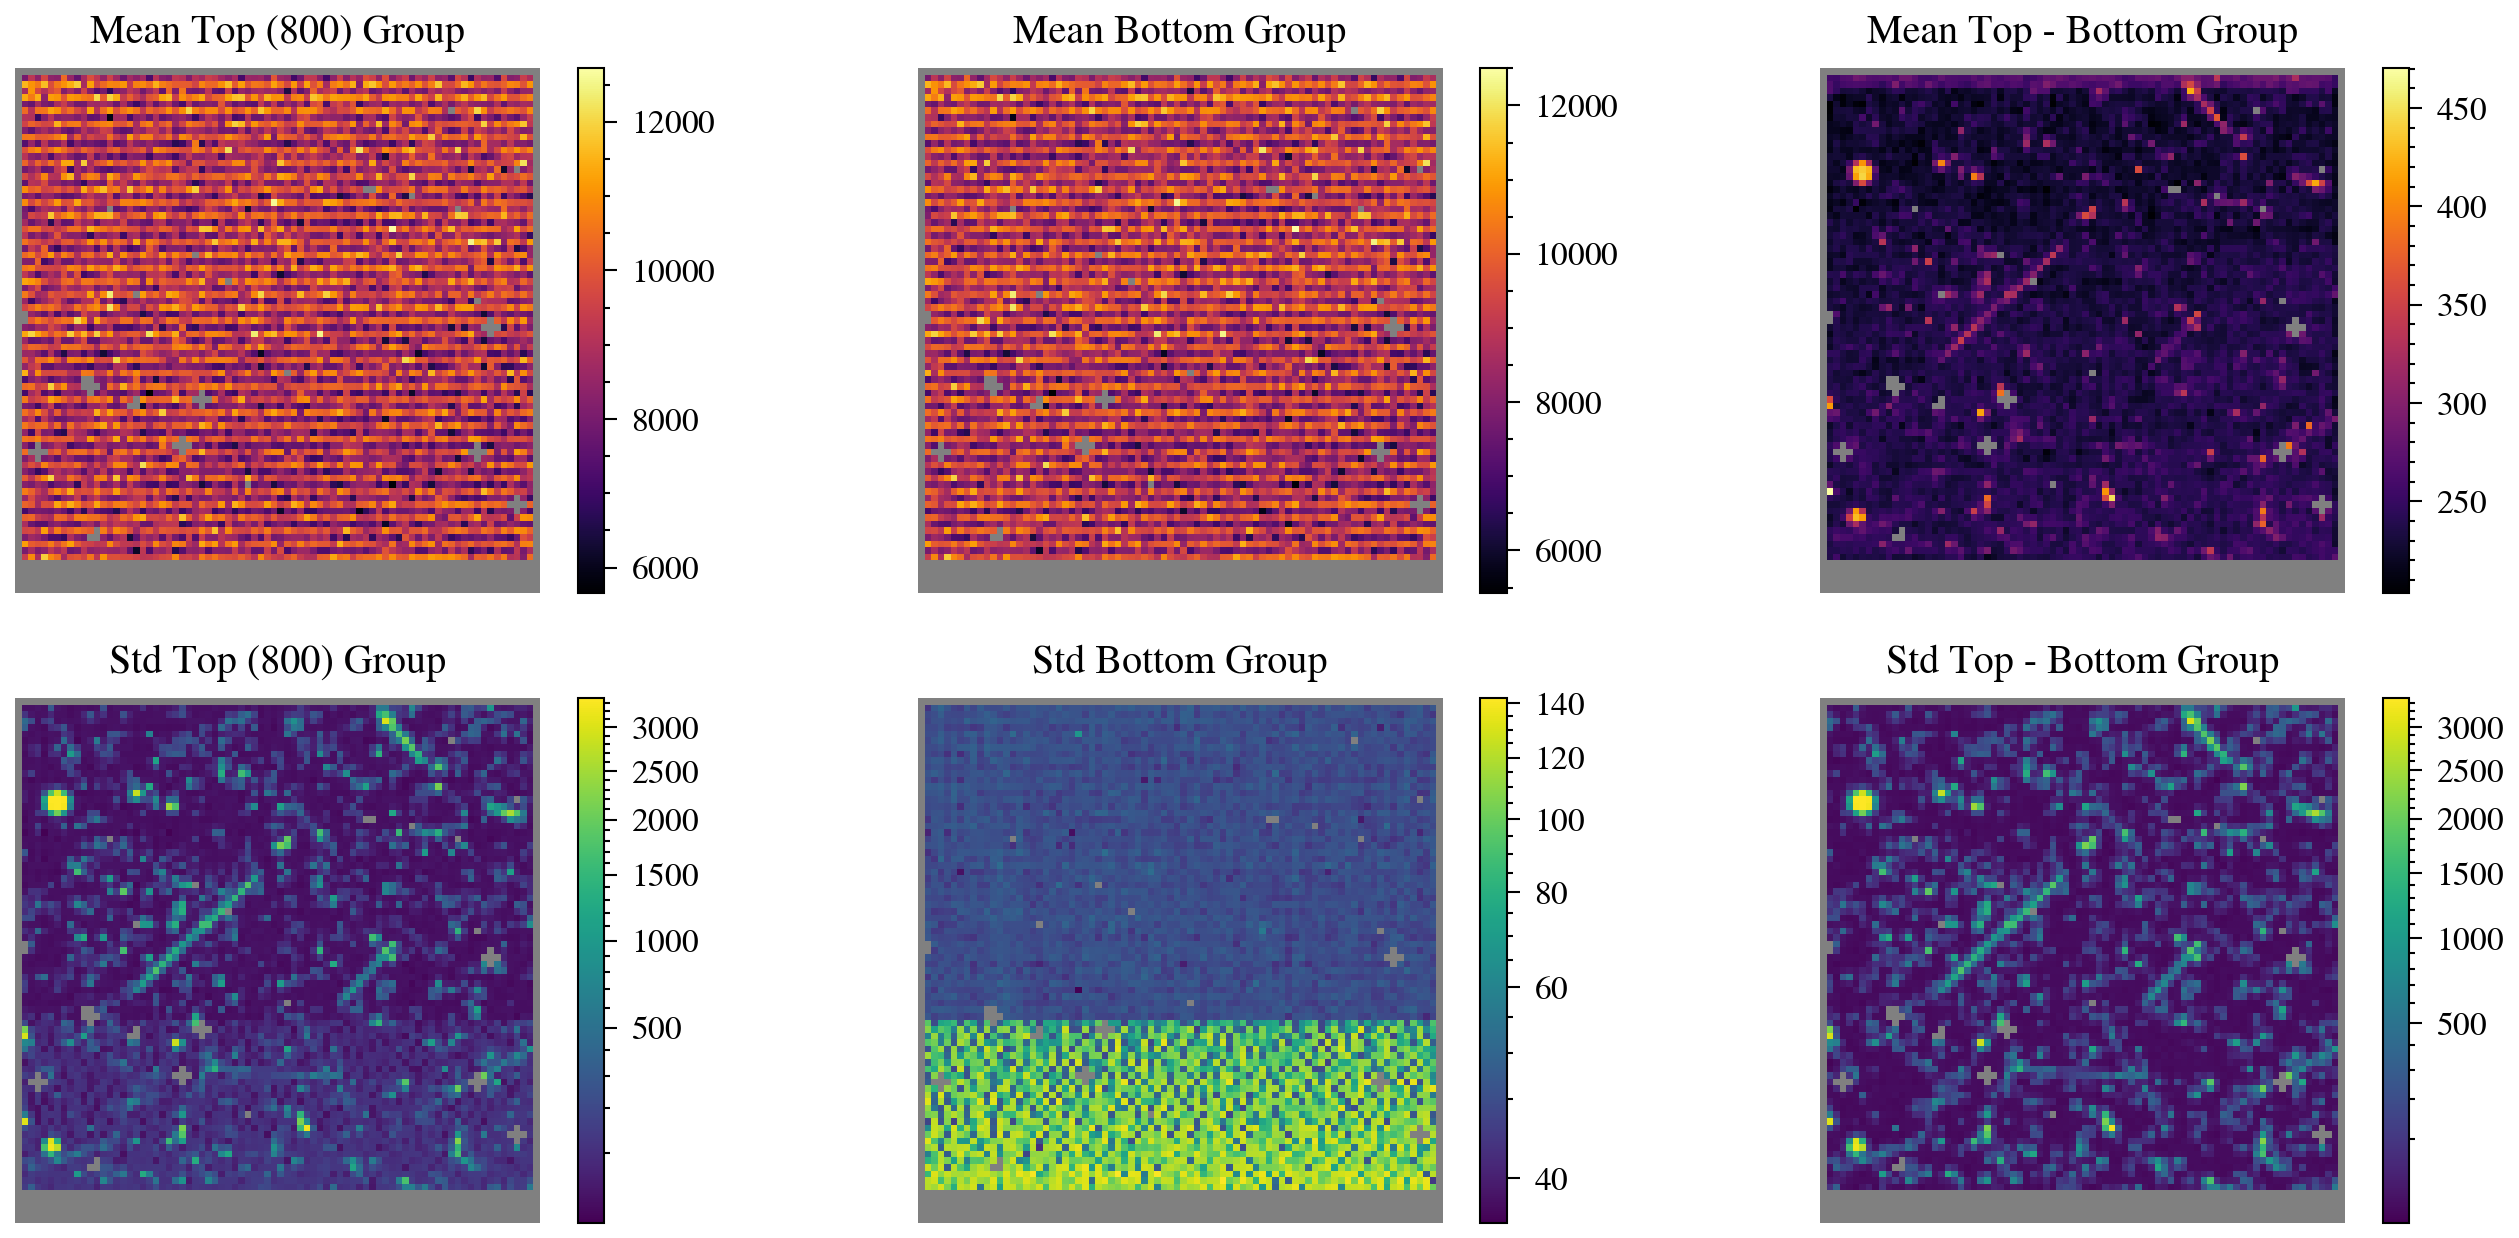

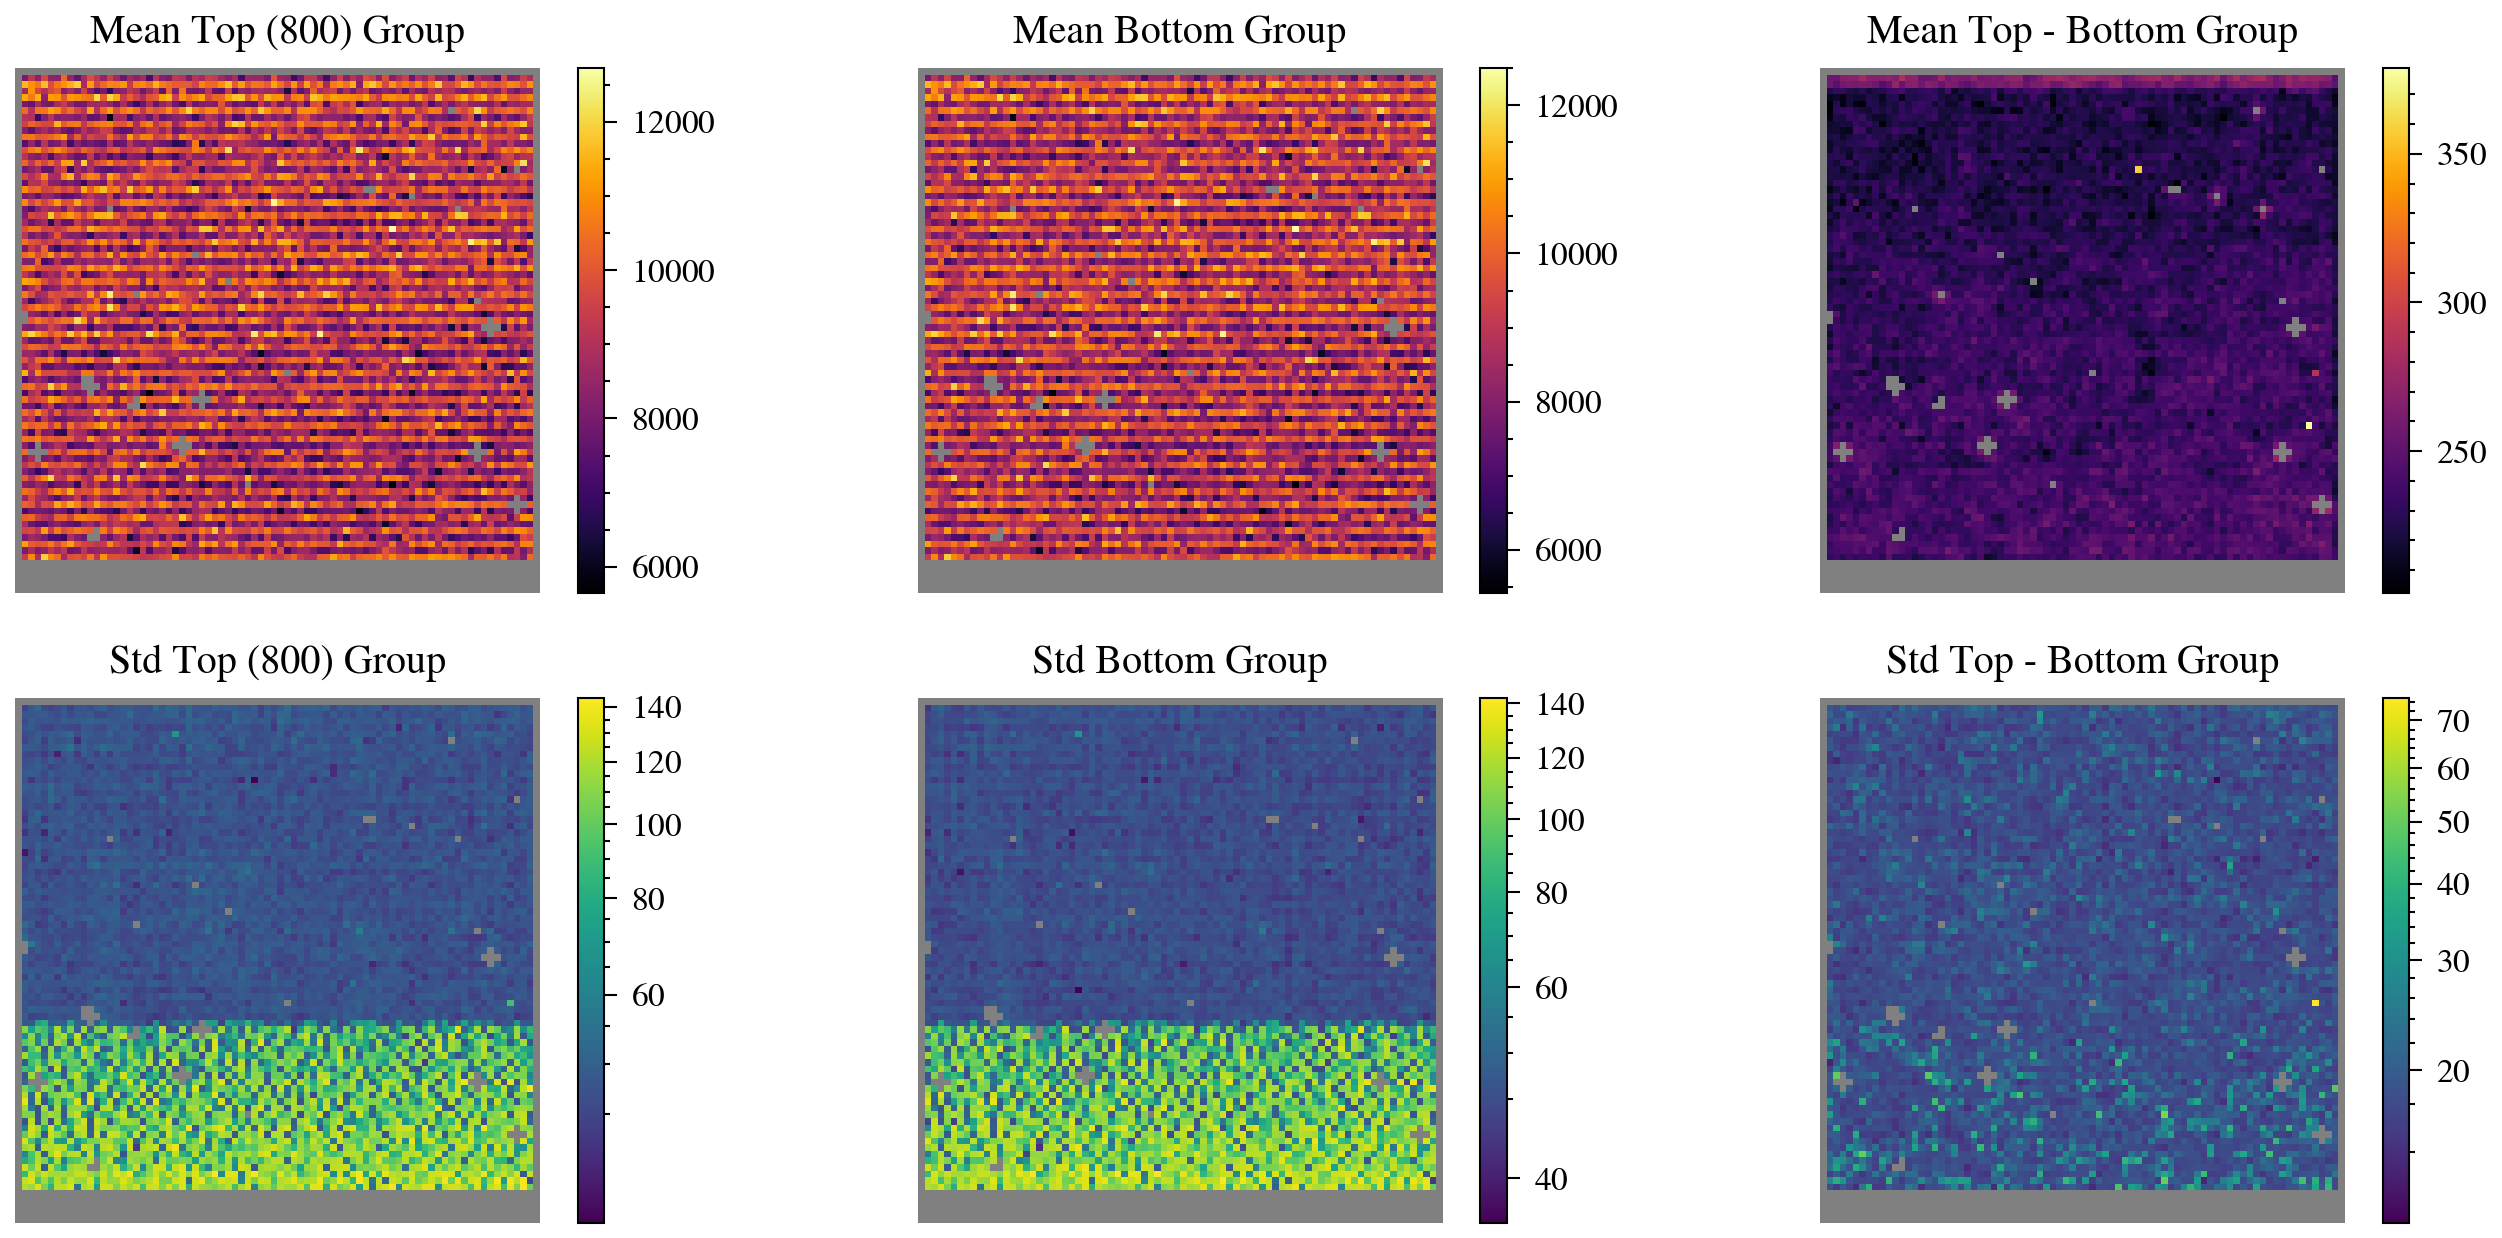

In [9]:
check_darks(data)
check_darks(clipped_data)

In [ ]:
# look at percentiles